# `jlegroup` tutorial — CE97 occultation light-curve forward modeling

This notebook is a guided tour of the **`jlegroup`** Python package: forward modeling of
stellar-occultation light curves with the **Chamberlain & Elliot (1997)** numerical method
(PASP 109, 1170 — *"A Numerical Method for Calculating Stellar Occultation Light Curves
from an Arbitrary Atmospheric Model"*).

**Naming convention:** all-lowercase `jlegroup` is this Python package; camelCase
`jleGroup` refers to the original Mathematica package family used within the group.

**Lineage:** original Python implementation by WataThep (2021), extended by William
Saunders (2021), packaged, validated, and maintained by Michael J. Person (2026).

The CE97 implementation reproduces independent EY92-family reference light curves to
**≲1×10⁻⁴** of the unocculted flux for clear atmospheres (the paper's accuracy claim);
the reference data ship with the package and run as its regression suite (see §5).

**Install** (collaborators on the private repo):
```
pip install git+https://github.com/mjperson/jlegroup.git
```

What we'll do:
1. Physical constants (`physicalData`)
2. Build a model atmosphere (`CE97.Atmosphere`)
3. Run the forward model in the observer plane
4. Time-domain light curves + noise
5. Validation against the bundled EY92 references — and the atmosphere-top gotcha
6. Thermal gradients (power-law temperature profiles)
7. Arbitrary profiles: a thermal inversion layer
8. Knobs, gotchas, citation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import jlegroup
from jlegroup import CE97, physicalData

print("jlegroup", jlegroup.__version__, "| numpy", np.__version__)

jlegroup 0.1.0 | numpy 2.5.0


## 1. Physical constants: `physicalData`

`jlegroup.physicalData` mirrors the Mathematica ``jleGroup`physicalData`` package.
The values are deliberately **CODATA-1986 vintage** — the vintage used by the Mathematica
package and therefore by every reference light curve this code is validated against.
Don't "upgrade" them without revalidating the benchmark suite.

In [2]:
print(f"Boltzmann k_B   = {physicalData.BOLTZMANN:.6e}  J/K")
print(f"Newton G        = {physicalData.GRAVITATIONAL:.5e}  m^3/(kg s^2)")
print(f"Avogadro N_A    = {physicalData.AVOGADRO:.7e}  /mol")
print(f"Loschmidt L     = {physicalData.LOSCHMIDT:.6e}  /m^3 (STP number density)")
print(f"AU              = {physicalData.AU_KM:.8e}  km")
print(f"N2 molar mass   = {physicalData.MOLAR_MASS['N2']*1e3:.2f} g/mol")
print()
nu07 = physicalData.refractivitySTP("N2", 0.7)
print(f"N2 refractivity at STP, 0.7 um : {nu07:.6e}   (Peck & Khanna 1966)")
print(f"  ... per molecule             : {nu07/physicalData.LOSCHMIDT:.6e} m^3")

Boltzmann k_B   = 1.380658e-23  J/K
Newton G        = 6.67259e-11  m^3/(kg s^2)
Avogadro N_A    = 6.0221367e+23  /mol
Loschmidt L     = 2.686763e+25  /m^3 (STP number density)
AU              = 1.49597871e+08  km
N2 molar mass   = 28.01 g/mol

N2 refractivity at STP, 0.7 um : 2.969636e-04   (Peck & Khanna 1966)
  ... per molecule             : 1.105284e-29 m^3


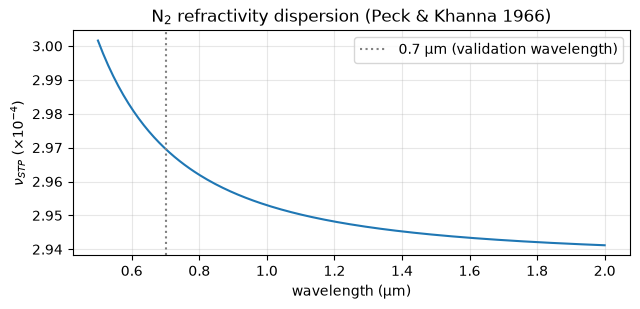

In [3]:
lam = np.linspace(0.5, 2.0, 200)
plt.figure(figsize=(6.5, 3.2))
plt.plot(lam, [physicalData.refractivitySTP("N2", l) * 1e4 for l in lam])
plt.axvline(0.7, color="gray", ls=":", label="0.7 µm (validation wavelength)")
plt.xlabel("wavelength (µm)"); plt.ylabel(r"$\nu_{STP}$ ($\times 10^{-4}$)")
plt.title("N$_2$ refractivity dispersion (Peck & Khanna 1966)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## 2. Build a model atmosphere

The forward model needs a **refractivity profile** ν(r). You can supply one directly
(from your own tables — see §5), or build one with the bundled atmosphere classes.

`CE97.Atmosphere` constructs a hydrostatic atmosphere from reference conditions at a
single radius, with a power-law temperature profile $T(r) = T_{ref}\,(r/r_{ref})^{b}$ and
full small-planet gravity $g(r) = GM/r^2$ (integrated by RK4). We use the test body from
the validation suite: a Triton/Pluto-class object, $M = 2.1398\times10^{22}$ kg, N₂
atmosphere between 1200 and 2500 km.

In [4]:
M_BODY = 2.1398e22        # kg
R_BASE = 1200.0           # km — bottom of the modeled atmosphere
R_TOP = 2500.0            # km — top of the modeled atmosphere
P_REF = 17.18             # Pa at R_BASE (= 171.8 microbar)
T_ISO = 114.5             # K

atm_iso = CE97.Atmosphere(
    referencePressure=P_REF,
    referenceTemperature=T_ISO,
    referenceRadius=R_BASE,
    planetRadius=R_BASE,                    # grid runs upward from here
    planetMass=M_BODY,
    meanMolecularMass=physicalData.MOLAR_MASS["N2"],   # kg/mol
    polarizability=None,
    refractivityAtSTP=physicalData.refractivitySTP("N2", 0.7),
    temperatureGradient=0.0,                # b = 0: isothermal
    topOfAtmosphere=R_TOP,
    resolution=1.0,                         # km
)
atm_iso.main()
atm_iso.atmosphericProfile.head()

,Radius,Temperature,Pressure,NumDensity,Refractivity
0,1200.0,114.5,17.180000,1.086762e+22,1.217089e-07
1,1201.0,114.5,16.687141,1.055585e+22,1.182173e-07
2,1202.0,114.5,16.209205,1.025352e+22,1.148314e-07
3,1203.0,114.5,15.745718,9.960333e+21,1.115479e-07
4,1204.0,114.5,15.296220,9.675992e+21,1.083635e-07


### A consistency note on refractivity (recommended pattern)

The atmosphere classes carry their own refractivity conversions, which predate
`physicalData` and use a slightly different STP convention (1 bar rather than 1 atm) and
2018-vintage internal constants. For consistency with the validated benchmarks,
**recompute ν from the number-density column with `physicalData.refractivity`** — that is
the convention every validation number in this package was measured with:

In [5]:
def model_refractivity(profile, wavelength_um=0.7):
    '''Refractivity profile from an atmosphericProfile DataFrame, physicalData convention.'''
    return physicalData.refractivity(profile["NumDensity"].to_numpy(), "N2", wavelength_um)

nu_iso = model_refractivity(atm_iso.atmosphericProfile)
ratio = float(np.mean(atm_iso.atmosphericProfile["Refractivity"].to_numpy() / nu_iso))
print(f"class-internal nu / physicalData nu = {ratio:.5f}  (~1.3%: 1 bar vs 1 atm STP)")

class-internal nu / physicalData nu = 1.01324  (~1.3%: 1 bar vs 1 atm STP)


g(1200 km) = 0.992 m/s^2 ; scale height H = 34.3 km


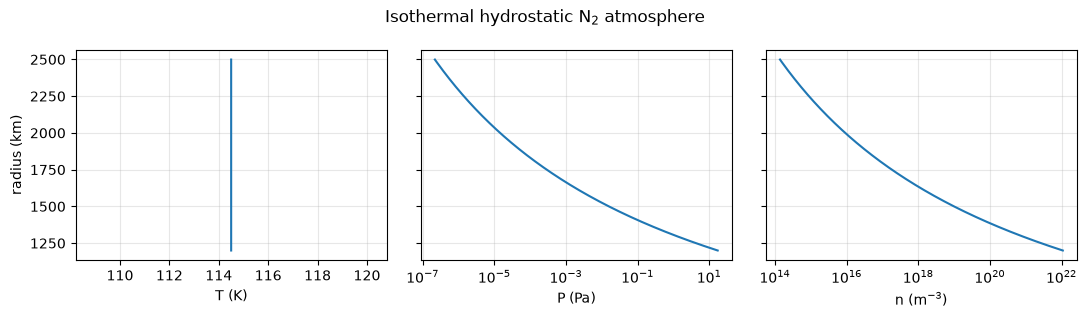

In [6]:
prof = atm_iso.atmosphericProfile
radius = prof["Radius"].to_numpy()

# pressure scale height at the base, H = kT/(m g)
m_molec = physicalData.MOLAR_MASS["N2"] / physicalData.AVOGADRO
g_base = physicalData.GRAVITATIONAL * M_BODY / (R_BASE * 1e3) ** 2
H_km = physicalData.BOLTZMANN * T_ISO / (m_molec * g_base) / 1e3
print(f"g({R_BASE:.0f} km) = {g_base:.3f} m/s^2 ; scale height H = {H_km:.1f} km")

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
ax[0].plot(prof["Temperature"], radius); ax[0].set_xlabel("T (K)"); ax[0].set_ylabel("radius (km)")
ax[1].semilogx(prof["Pressure"], radius); ax[1].set_xlabel("P (Pa)")
ax[2].semilogx(prof["NumDensity"], radius); ax[2].set_xlabel(r"n (m$^{-3}$)")
for a in ax: a.grid(alpha=0.3)
fig.suptitle("Isothermal hydrostatic N$_2$ atmosphere"); fig.tight_layout()

## 3. The forward model in the observer plane

`CE97.ChamberlainElliot1997Model` takes the refractivity profile and computes, for each
position $y$ in the observer plane:

- the bending angle $\theta(r)$ (numerical integral through the atmosphere),
- the mapping $y = r + D\,\theta(r)$ from observer plane to planet plane
  (**all** geometric images at each $y$ are found and summed, via `ray_crossing`),
- the normalized stellar flux, with (`focusedFlux`) and without (`unfocusedFlux`)
  the far-limb focusing factor.

Distances are in km. Here the observer is at 30 AU.

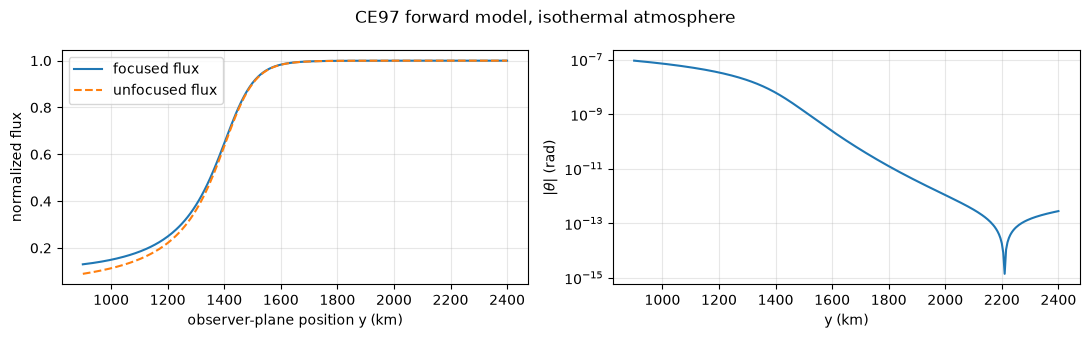

In [7]:
D_KM = 30 * physicalData.AU_KM

position = np.arange(900.0, 2401.0, 5.0)     # km in the observer plane
m_iso = CE97.ChamberlainElliot1997Model(
    refractivityProfile=nu_iso,
    radialDistance=radius,
    planetDistance=D_KM,
    position=position,
)
m_iso.main()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(position, m_iso.focusedFlux, label="focused flux")
ax[0].plot(position, m_iso.unfocusedFlux, "--", label="unfocused flux")
ax[0].set_xlabel("observer-plane position y (km)"); ax[0].set_ylabel("normalized flux")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].semilogy(position, np.abs(m_iso.theta))
ax[1].set_xlabel("y (km)"); ax[1].set_ylabel(r"|$\theta$| (rad)"); ax[1].grid(alpha=0.3)
fig.suptitle("CE97 forward model, isothermal atmosphere"); fig.tight_layout()

## 4. Time-domain light curves + noise

An observer records flux against **time**. For a chord with closest approach $b$ and
shadow velocity $v$: $y(t) = \sqrt{b^2 + (v\,t)^2}$.

We keep $|t|$ modest here so that $y$ stays below the top of the modeled atmosphere —
§5 explains what happens (and what to do) beyond it.

For simulated observations, the model can add Gaussian noise: pass `snrPerScaleHeight`
together with `scaleHeight` (and `observerPlaneSampling`, the km per exposure); the
noisy curve lands in `fluxWithNoiseAdded`.

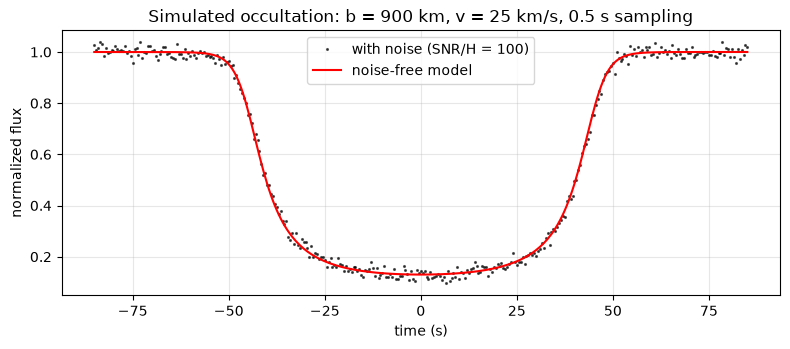

In [8]:
b_km, v_kms, dt_s = 900.0, 25.0, 0.5
t = np.arange(-85.0, 85.0 + dt_s, dt_s)
y_t = np.sqrt(b_km**2 + (v_kms * t) ** 2)

np.random.seed(0)
m_time = CE97.ChamberlainElliot1997Model(
    refractivityProfile=nu_iso, radialDistance=radius, planetDistance=D_KM, position=y_t,
    snrPerScaleHeight=100.0, scaleHeight=H_km, observerPlaneSampling=v_kms * dt_s,
)
m_time.main()

plt.figure(figsize=(8, 3.6))
plt.plot(t, m_time.fluxWithNoiseAdded, "k.", ms=2.5, alpha=0.6, label="with noise (SNR/H = 100)")
plt.plot(t, m_time.focusedFlux, "r-", lw=1.5, label="noise-free model")
plt.xlabel("time (s)"); plt.ylabel("normalized flux")
plt.title(f"Simulated occultation: b = {b_km:.0f} km, v = {v_kms:.0f} km/s, {dt_s} s sampling")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## 5. Validation — and the atmosphere-top gotcha

The package bundles three machine-exact reference cases (`tests/data/`), generated
independently with the Mathematica jleGroup `olcOneLimb2` model (EY92 family) at
λ = 0.7 µm. Here we load **iso-clear** and reproduce it from its atmosphere table.

**The gotcha:** the model's $y \to r$ spline only reaches
$y_{top} = r_{top} + D\,\theta(r_{top})$. Positions beyond that are spline
**extrapolation** — whatever the model returns there is *not physics* and can include
spurious caustic-like spikes. Physically those rays pass **above** the modeled atmosphere
(vacuum), so their flux is exactly 1: **clamp them**, as below. (Corollary: build your
atmosphere table to extend well above the flux-recovery altitude; a truncated top also
leaves a ~10⁻³ spline edge artifact within ~2 scale heights of the boundary.)

In [9]:
DATA = Path("..") / "tests" / "data"
if not (DATA / "iso-clear").exists():        # fallback if running from the repo root
    DATA = Path("tests") / "data"

def mfloat(s):
    '''Parse Mathematica-formatted floats like 1.086*10^22.'''
    return float(str(s).replace("*10^", "e").replace("*^", "e"))

def load_case(case):
    d = DATA / case
    atm = pd.read_csv(d / "atmosphere.csv")
    atm.columns = [c.strip() for c in atm.columns]
    r = atm["Radius (km)"].apply(mfloat).to_numpy()
    n = atm["Number Density (/m^3)"].apply(mfloat).to_numpy()
    lc = pd.read_csv(d / "lightcurve.csv")
    return r, n, lc["Time (seconds)"].to_numpy(float), lc["Flux (normalized)"].to_numpy(float)

r_b, n_b, t_b, f_ref = load_case("iso-clear")
nu_b = physicalData.refractivity(n_b)                  # the validated convention
y_b = np.sqrt(900.0**2 + (25.0 * t_b) ** 2)

mdl = CE97.ChamberlainElliot1997Model(nu_b, r_b, D_KM, y_b)
mdl.main()
f_raw = np.asarray(mdl.focusedFlux, float)

# the top of the mapped atmosphere:
x0 = np.arange(0, r_b[-1], mdl.integrationBin)
y_top = r_b.max() + D_KM * 2 * np.trapezoid(mdl.integrandTheta(x0, r_b.max()), x0)
t_top = np.sqrt(y_top**2 - 900.0**2) / 25.0
print(f"y_top = {y_top:.1f} km  ->  |t| > {t_top:.1f} s is above the modeled atmosphere")

f_model = f_raw.copy()
f_model[y_b > y_top] = 1.0                              # vacuum: flux = 1 exactly

y_top = 2500.0 km  ->  |t| > 93.3 s is above the modeled atmosphere


max |model - reference| = 4.244e-05
RMS residual            = 1.474e-05


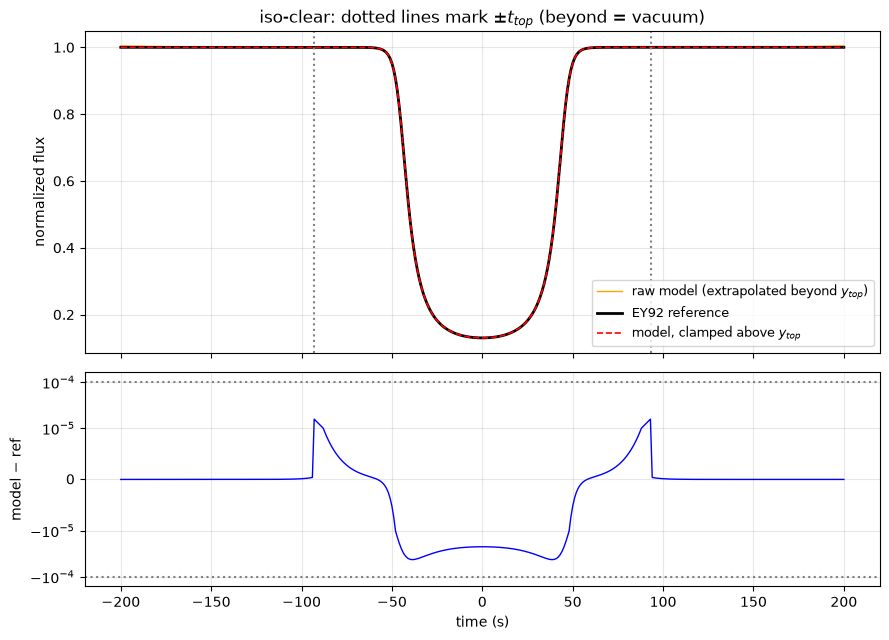

In [10]:
resid = f_model - f_ref
print(f"max |model - reference| = {np.max(np.abs(resid)):.3e}")
print(f"RMS residual            = {np.sqrt(np.mean(resid**2)):.3e}")

fig, ax = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                       gridspec_kw={"height_ratios": [3, 2]})
ax[0].plot(t_b, f_raw, color="orange", lw=1, label="raw model (extrapolated beyond $y_{top}$)")
ax[0].plot(t_b, f_ref, "k-", lw=2, label="EY92 reference")
ax[0].plot(t_b, f_model, "r--", lw=1.2, label="model, clamped above $y_{top}$")
for s in (-1, 1):
    ax[0].axvline(s * t_top, color="gray", ls=":")
ax[0].set_ylabel("normalized flux"); ax[0].legend(loc="lower right", fontsize=9); ax[0].grid(alpha=0.3)
ax[0].set_title("iso-clear: dotted lines mark $\\pm t_{top}$ (beyond = vacuum)")
ax[1].plot(t_b, resid, "b-", lw=1)
ax[1].axhline(1e-4, color="gray", ls=":"); ax[1].axhline(-1e-4, color="gray", ls=":")
ax[1].set_yscale("symlog", linthresh=1e-5)
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("model $-$ ref"); ax[1].grid(alpha=0.3)
fig.tight_layout()

The full validation suite (run automatically by `pytest`):

| case | temperature profile | max \|model − ref\| |
|---|---|---|
| iso-clear | $T \propto r^{0}$ (114.5 K) | 4.2 × 10⁻⁵ |
| shallow-clear | $T \propto r^{-0.5}$ | 9.7 × 10⁻⁵ |
| steep-clear | $T \propto r^{-4.5}$ | 1.1 × 10⁻³ * |

\* The steep-clear residual is dominated by the *reference's* first-order-in-1/λ EY92
series truncation, not by CE97 — the neglected $O(\lambda^{-2})$ term's coefficient,
$(9 - 34b + 25b^2)/128$, grows from 0.07 (isothermal) to 5.2 at $b=-4.5$ and
quantitatively predicts the miss.

## 6. Thermal gradients

CE97's purpose is light curves from **arbitrary** atmospheric structure. The
`temperatureGradient` argument gives the power-law family $T \propto r^b$ directly —
here the same three members as the validation suite. Steeper (more negative) $b$ means a
colder, more compact upper atmosphere and a visibly different curve shape.

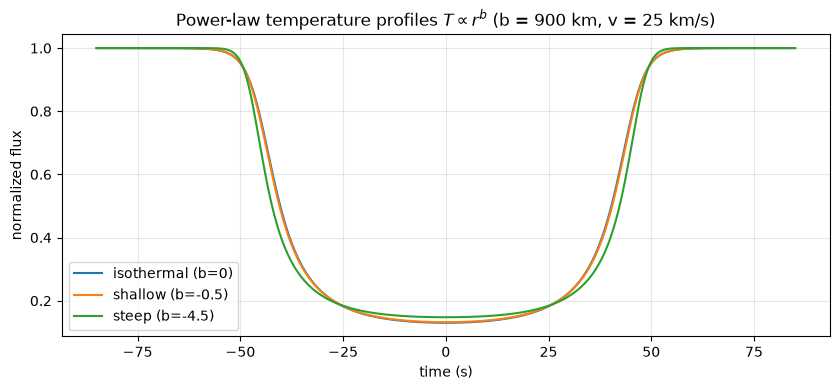

In [11]:
cases = {0.0: ("isothermal (b=0)", 114.5),
         -0.5: ("shallow (b=-0.5)", 118.8),
         -4.5: ("steep (b=-4.5)", 166.7)}

plt.figure(figsize=(8.5, 4))
for b, (label, T_ref) in cases.items():
    a = CE97.Atmosphere(
        referencePressure=P_REF, referenceTemperature=T_ref, referenceRadius=R_BASE,
        planetRadius=R_BASE, planetMass=M_BODY,
        meanMolecularMass=physicalData.MOLAR_MASS["N2"],
        polarizability=None, refractivityAtSTP=physicalData.refractivitySTP("N2", 0.7),
        temperatureGradient=b, topOfAtmosphere=R_TOP, resolution=1.0)
    a.main()
    m = CE97.ChamberlainElliot1997Model(
        model_refractivity(a.atmosphericProfile),
        a.atmosphericProfile["Radius"].to_numpy(), D_KM, y_t)
    m.main()
    plt.plot(t, m.focusedFlux, label=label)

plt.xlabel("time (s)"); plt.ylabel("normalized flux")
plt.title(r"Power-law temperature profiles $T \propto r^{b}$ (b = 900 km, v = 25 km/s)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## 7. Arbitrary profiles: a thermal inversion layer

For structure beyond power laws there are two profile-driven builders:

- `CE97.AtmospherefromTprofile` — you supply $T(r)$ on a radius grid;
- `CE97.AtmospherefromTpProfile` — you supply $T(p)$ on a pressure grid
  (the radius grid is solved for hydrostatically).

Here: an isothermal atmosphere with a **30 K Gaussian warm layer** at 1500 km. The layer
perturbs the refractivity gradient and imprints a clear signature on the light curve.

*Implementation note:* the CE97 derivative machinery works on $\ln\nu$ and $\ln(-d\nu/dr)$,
so it requires refractivity to decrease monotonically with radius ($d\nu/dr < 0$
everywhere). Gentle layers like this one are fine; a layer sharp enough to reverse the
density gradient will break the log-splines.

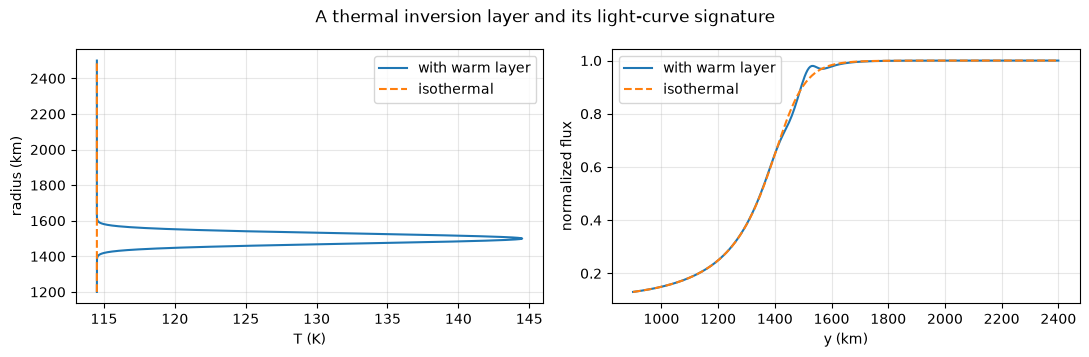

In [12]:
r_grid = np.arange(1200.0, 2501.0, 1.0)
T_layer = 114.5 + 30.0 * np.exp(-(((r_grid - 1500.0) / 40.0) ** 2))

atm_layer = CE97.AtmospherefromTprofile(
    referencePressure=P_REF, referenceRadius=R_BASE,
    temperatureProfile=T_layer, radius=r_grid,
    planetRadius=R_BASE, planetMass=M_BODY,
    meanMolecularMass=physicalData.MOLAR_MASS["N2"],
    polarizability=None, refractivityAtSTP=physicalData.refractivitySTP("N2", 0.7),
)
atm_layer.main()

m_layer = CE97.ChamberlainElliot1997Model(
    model_refractivity(atm_layer.atmosphericProfile), r_grid, D_KM, position)
m_layer.main()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(T_layer, r_grid, label="with warm layer")
ax[0].plot(np.full_like(r_grid, 114.5), r_grid, "--", label="isothermal")
ax[0].set_xlabel("T (K)"); ax[0].set_ylabel("radius (km)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(position, m_layer.focusedFlux, label="with warm layer")
ax[1].plot(position, m_iso.focusedFlux, "--", label="isothermal")
ax[1].set_xlabel("y (km)"); ax[1].set_ylabel("normalized flux"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle("A thermal inversion layer and its light-curve signature"); fig.tight_layout()

## 8. Knobs, gotchas, citation

**Performance/accuracy knobs** (attributes on `ChamberlainElliot1997Model`, both 1.5 km
by default): `splineResolution` (grid for the $y \to r$ spline) and `integrationBin`
(step for the $\theta$ integrals). The validation campaign found results insensitive to
these from 1.5 km down to 0.1 km for the bundled cases.

**Gotchas recap**
1. Clamp flux to 1 for positions above $y_{top}$ (§5) — and extend your atmosphere table
   well above the flux-recovery altitude.
2. Refractivity must decrease monotonically with radius (§7).
3. Use `physicalData` for constants and refractivity conversions (§2) — its CODATA-1986
   vintage matches the validation references; don't mix conventions.
4. The bundled references are one-limb curves; the model itself sums all geometric
   images (negligible far-limb flux for the bundled geometry).

**Citing this work:** please cite Chamberlain & Elliot (1997), PASP 109, 1170, and the
package (see `CITATION.cff`).

**Status:** private during development; MIT license pending lineage-author permissions.
`jlegroup.EY92` (Elliot & Young 1992, AJ 103, 991) is now part of the package — an
analytic small-planet model cross-validated against CE97 and the paper's own benchmark
tables (`from jlegroup import EY92`). Note it defaults to `seriesOrder=4`; pass
`seriesOrder=1` to reproduce Mathematica jleGroup curves, and `twoLimb=True` (with `surfaceRadius=`) for far-limb/central-flash curves. `jlegroup.EPQ03` (Elliot, Person & Qu 2003, AJ 126, 1041) closes the loop: light-curve **inversion** and atmospheric retrieval with full error propagation (`from jlegroup import EPQ03`; start at `EPQ03.invert_light_curve`).